In [2]:
%pip install torchvision --break-system-packages

In [9]:
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import pandas as pd

from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt



SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print("Using device:", device)



BATCH_SIZE = 64
LEARNING_RATE = 0.001
EPOCHS = 50

DROPOUT_RATE = 0.5
WEIGHT_DECAY = 1e-4

TRAIN_SIZE = 54000
VAL_SIZE = 6000



transform = transforms.Compose([
    transforms.ToTensor(),

    transforms.Normalize((0.5,), (0.5,))
])


full_train_set = torchvision.datasets.FashionMNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)


test_set = torchvision.datasets.FashionMNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)


split_generator = torch.Generator().manual_seed(SEED)

train_set, val_set = random_split(
    full_train_set,
    [TRAIN_SIZE, VAL_SIZE],
    generator=split_generator
)


train_loader = DataLoader(
    train_set,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_set,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_set,
    batch_size=BATCH_SIZE,
    shuffle=False
)


print(f"Training samples:   {len(train_set)}")
print(f"Validation samples: {len(val_set)}")
print(f"Test samples:       {len(test_set)}")




class LeNet5Base(nn.Module):

    def __init__(self):
        super().__init__()

        # Input: 1 x 28 x 28

        # Output: 6 x 28 x 28
        self.conv1 = nn.Conv2d(
            in_channels=1,
            out_channels=6,
            kernel_size=5,
            padding=2
        )

        # Output after pooling: 6 x 14 x 14
        self.pool1 = nn.AvgPool2d(
            kernel_size=2,
            stride=2
        )

        # Output: 16 x 10 x 10
        self.conv2 = nn.Conv2d(
            in_channels=6,
            out_channels=16,
            kernel_size=5
        )

        # Output after pooling: 16 x 5 x 5
        self.pool2 = nn.AvgPool2d(
            kernel_size=2,
            stride=2
        )

        # Fully connected layers
        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

        self.relu = nn.ReLU()


    def forward(self, x):

        x = self.conv1(x)
        x = self.relu(x)
        x = self.pool1(x)

        x = self.conv2(x)
        x = self.relu(x)
        x = self.pool2(x)

        x = torch.flatten(x, 1)

        x = self.fc1(x)
        x = self.relu(x)

        x = self.fc2(x)
        x = self.relu(x)

        x = self.fc3(x)

        return x



class LeNet5Dropout(nn.Module):

    def __init__(self, dropout_rate=0.5):
        super().__init__()

        self.conv1 = nn.Conv2d(
            1,
            6,
            kernel_size=5,
            padding=2
        )

        self.pool1 = nn.AvgPool2d(2, 2)

        self.conv2 = nn.Conv2d(
            6,
            16,
            kernel_size=5
        )

        self.pool2 = nn.AvgPool2d(2, 2)

        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        self.dropout1 = nn.Dropout(dropout_rate)

        self.fc2 = nn.Linear(120, 84)
        self.dropout2 = nn.Dropout(dropout_rate)

        self.fc3 = nn.Linear(84, 10)

        self.relu = nn.ReLU()


    def forward(self, x):

        x = self.conv1(x)
        x = self.relu(x)
        x = self.pool1(x)

        x = self.conv2(x)
        x = self.relu(x)
        x = self.pool2(x)

        x = torch.flatten(x, 1)

        x = self.fc1(x)
        x = self.relu(x)
        x = self.dropout1(x)

        x = self.fc2(x)
        x = self.relu(x)
        x = self.dropout2(x)

        x = self.fc3(x)

        return x


class LeNet5BatchNorm(nn.Module):

    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(
            1,
            6,
            kernel_size=5,
            padding=2
        )

        self.bn1 = nn.BatchNorm2d(6)

        self.pool1 = nn.AvgPool2d(2, 2)

        self.conv2 = nn.Conv2d(
            6,
            16,
            kernel_size=5
        )

        self.bn2 = nn.BatchNorm2d(16)

        self.pool2 = nn.AvgPool2d(2, 2)

        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        self.bn_fc1 = nn.BatchNorm1d(120)

        self.fc2 = nn.Linear(120, 84)
        self.bn_fc2 = nn.BatchNorm1d(84)

        self.fc3 = nn.Linear(84, 10)

        self.relu = nn.ReLU()


    def forward(self, x):

        # Conv -> BatchNorm -> ReLU -> Pool
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.pool1(x)

        x = self.conv2(x)
        x = self.bn2(x)
        x = self.relu(x)
        x = self.pool2(x)

        x = torch.flatten(x, 1)

        # FC -> BatchNorm -> ReLU
        x = self.fc1(x)
        x = self.bn_fc1(x)
        x = self.relu(x)

        x = self.fc2(x)
        x = self.bn_fc2(x)
        x = self.relu(x)

        x = self.fc3(x)

        return x


def compute_accuracy(model, loader):


    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            predicted = torch.argmax(
                outputs,
                dim=1
            )

            total += labels.size(0)

            correct += (
                predicted == labels
            ).sum().item()

    accuracy = 100.0 * correct / total

    return accuracy



def run_experiment(
    model,
    name,
    save_filename,
    weight_decay=0.0,
    epochs=10
):

    print("\n" + "=" * 70)
    print(f"Training: {name}")
    print("=" * 70)

    model = model.to(device)

    criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(
        model.parameters(),
        lr=LEARNING_RATE,
        weight_decay=weight_decay
    )

    train_acc_history = []
    val_acc_history = []
    test_acc_history = []


    best_val_acc = -1.0
    best_epoch = 0


    for epoch in range(epochs):



        model.train()

        running_loss = 0.0

        for images, labels in train_loader:

            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )

            loss.backward()

            optimizer.step()

            running_loss += (
                loss.item() * images.size(0)
            )


        average_loss = (
            running_loss /
            len(train_loader.dataset)
        )



        train_acc = compute_accuracy(
            model,
            train_loader
        )

        val_acc = compute_accuracy(
            model,
            val_loader
        )


        # test_acc = compute_accuracy(
        #     model,
        #     test_loader
        # )


        train_acc_history.append(
            train_acc
        )

        val_acc_history.append(
            val_acc
        )

        # test_acc_history.append(
        #     test_acc
        # )


        print(
            f"Epoch [{epoch + 1:2d}/{epochs}] "
            f"| Loss: {average_loss:.4f} "
            f"| Train Acc: {train_acc:.2f}% "
            f"| Val Acc: {val_acc:.2f}% "
            # f"| Test Acc: {test_acc:.2f}%"
        )


        if val_acc > best_val_acc:

            best_val_acc = val_acc
            best_epoch = epoch + 1

            torch.save(
                model.state_dict(),
                save_filename
            )



    model.load_state_dict(
        torch.load(
            save_filename,
            map_location=device
        )
    )


    # Evaluate the selected best-validation model
    final_train_acc = compute_accuracy(
        model,
        train_loader
    )

    final_val_acc = compute_accuracy(
        model,
        val_loader
    )

    final_test_acc = compute_accuracy(
        model,
        test_loader
    )


    print("\nBest Model Selection")
    print("-" * 70)

    print(
        f"Best epoch:               {best_epoch}"
    )

    print(
        f"Best validation accuracy: {best_val_acc:.2f}%"
    )

    print(
        f"Selected Train Accuracy:  {final_train_acc:.2f}%"
    )

    print(
        f"Selected Test Accuracy:   {final_test_acc:.2f}%"
    )

    print(
        f"Model saved to:           {save_filename}"
    )


    return {

        "train_history":
            train_acc_history,

        "val_history":
            val_acc_history,

        # "test_history":
        #     test_acc_history,

        "best_epoch":
            best_epoch,

        "best_val":
            best_val_acc,

        "final_train":
            final_train_acc,

        "final_val":
            final_val_acc,

        "final_test":
            final_test_acc
    }
results = {}

Using device: cuda
Training samples:   54000
Validation samples: 6000
Test samples:       10000


In [7]:
def plot(result, title="Model"):
    epochs_range = range(1, len(result["train_history"]) + 1)

    plt.figure(figsize=(8, 6))

    plt.plot(
        epochs_range,
        result["train_history"],
        marker="o",
        label="Train Accuracy"
    )

    plt.plot(
        epochs_range,
        result["val_history"],
        marker="s",
        label="Test (Validation) Accuracy"
    )

    plt.title(title, fontsize=14, fontweight="bold")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy (%)")
    plt.xticks(range(10, len(result["train_history"]) + 1, 10))
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

In [9]:
model1=LeNet5Base()

results["Base"] = run_experiment(

    model=model1,

    name="Base LeNet-5 (No Regularization)",

    save_filename="lenet5_base.pth",

    weight_decay=0.0,

    epochs=EPOCHS
)


Training: Base LeNet-5 (No Regularization)
Epoch [ 1/50] | Loss: 0.6551 | Train Acc: 83.02% | Val Acc: 82.40% 
Epoch [ 2/50] | Loss: 0.4207 | Train Acc: 86.26% | Val Acc: 85.92% 
Epoch [ 3/50] | Loss: 0.3613 | Train Acc: 87.59% | Val Acc: 86.40% 
Epoch [ 4/50] | Loss: 0.3263 | Train Acc: 88.77% | Val Acc: 87.95% 
Epoch [ 5/50] | Loss: 0.2989 | Train Acc: 89.67% | Val Acc: 88.08% 
Epoch [ 6/50] | Loss: 0.2799 | Train Acc: 90.60% | Val Acc: 88.80% 
Epoch [ 7/50] | Loss: 0.2628 | Train Acc: 90.86% | Val Acc: 89.28% 
Epoch [ 8/50] | Loss: 0.2486 | Train Acc: 91.68% | Val Acc: 89.80% 
Epoch [ 9/50] | Loss: 0.2345 | Train Acc: 91.71% | Val Acc: 89.73% 
Epoch [10/50] | Loss: 0.2222 | Train Acc: 92.40% | Val Acc: 90.18% 
Epoch [11/50] | Loss: 0.2098 | Train Acc: 92.40% | Val Acc: 90.08% 
Epoch [12/50] | Loss: 0.2011 | Train Acc: 93.59% | Val Acc: 90.43% 
Epoch [13/50] | Loss: 0.1908 | Train Acc: 93.75% | Val Acc: 90.50% 
Epoch [14/50] | Loss: 0.1824 | Train Acc: 93.99% | Val Acc: 90.48% 
Epoc

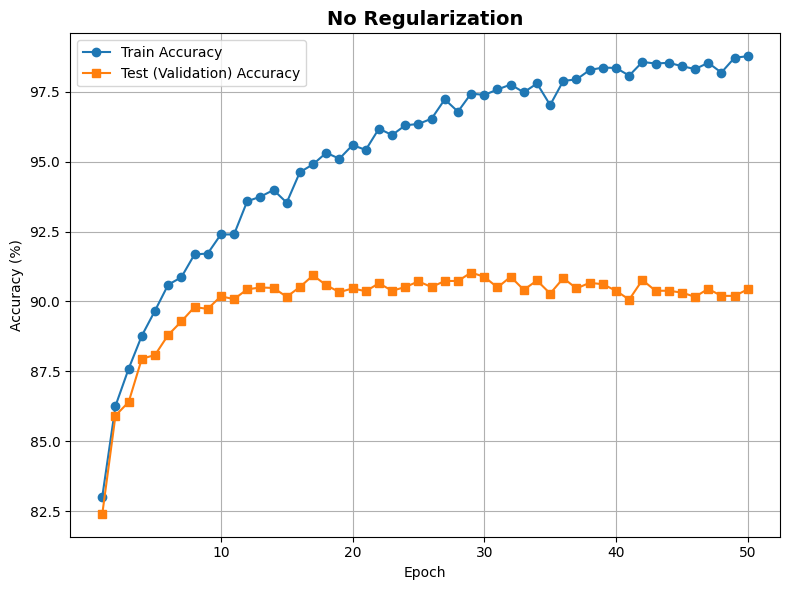

In [18]:
plot(results["Base"], "No Regularization")

In [10]:
model2=LeNet5Dropout(
        dropout_rate=DROPOUT_RATE
    )

results["Dropout"] = run_experiment(

    model=model2,

    name="LeNet-5 + Dropout",

    save_filename="lenet5_dropout.pth",

    weight_decay=0.0,

    epochs=EPOCHS
)



Training: LeNet-5 + Dropout
Epoch [ 1/50] | Loss: 0.8653 | Train Acc: 78.46% | Val Acc: 78.30% 
Epoch [ 2/50] | Loss: 0.5906 | Train Acc: 83.27% | Val Acc: 82.60% 
Epoch [ 3/50] | Loss: 0.5181 | Train Acc: 84.16% | Val Acc: 83.88% 
Epoch [ 4/50] | Loss: 0.4737 | Train Acc: 86.32% | Val Acc: 85.30% 
Epoch [ 5/50] | Loss: 0.4386 | Train Acc: 87.84% | Val Acc: 87.28% 
Epoch [ 6/50] | Loss: 0.4138 | Train Acc: 88.09% | Val Acc: 87.17% 
Epoch [ 7/50] | Loss: 0.3929 | Train Acc: 88.92% | Val Acc: 87.98% 
Epoch [ 8/50] | Loss: 0.3762 | Train Acc: 89.50% | Val Acc: 88.60% 
Epoch [ 9/50] | Loss: 0.3646 | Train Acc: 89.79% | Val Acc: 88.68% 
Epoch [10/50] | Loss: 0.3550 | Train Acc: 90.08% | Val Acc: 89.07% 
Epoch [11/50] | Loss: 0.3452 | Train Acc: 90.34% | Val Acc: 88.92% 
Epoch [12/50] | Loss: 0.3327 | Train Acc: 89.93% | Val Acc: 88.62% 
Epoch [13/50] | Loss: 0.3306 | Train Acc: 90.56% | Val Acc: 88.83% 
Epoch [14/50] | Loss: 0.3200 | Train Acc: 91.19% | Val Acc: 89.63% 
Epoch [15/50] | Los

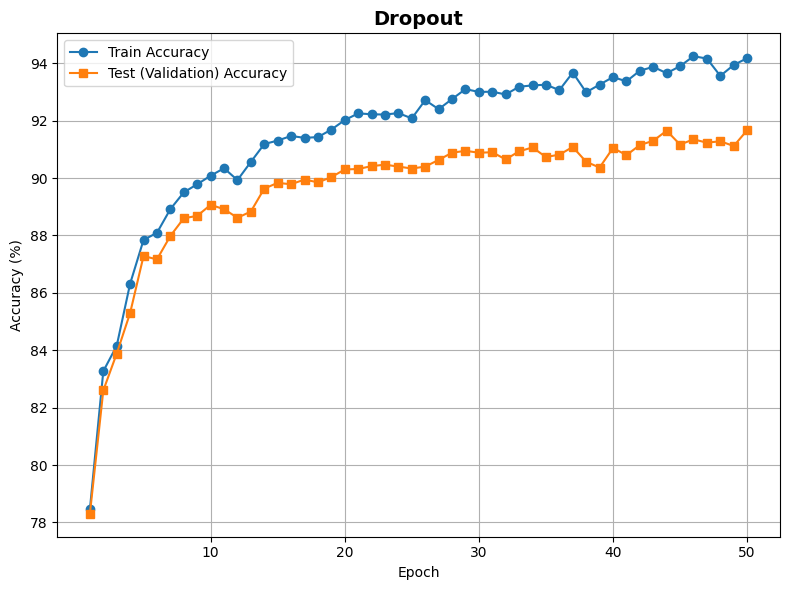

In [19]:
plot(results["Dropout"], "Dropout")

In [11]:


results["Weight Decay"] = run_experiment(

    model=LeNet5Base(),

    name="LeNet-5 + Weight Decay (L2)",

    save_filename="lenet5_weight_decay.pth",

    weight_decay=WEIGHT_DECAY,

    epochs=EPOCHS
)



Training: LeNet-5 + Weight Decay (L2)
Epoch [ 1/50] | Loss: 0.6746 | Train Acc: 82.31% | Val Acc: 81.90% 
Epoch [ 2/50] | Loss: 0.4346 | Train Acc: 85.67% | Val Acc: 84.62% 
Epoch [ 3/50] | Loss: 0.3720 | Train Acc: 87.29% | Val Acc: 86.07% 
Epoch [ 4/50] | Loss: 0.3392 | Train Acc: 88.66% | Val Acc: 87.55% 
Epoch [ 5/50] | Loss: 0.3136 | Train Acc: 87.90% | Val Acc: 86.47% 
Epoch [ 6/50] | Loss: 0.2932 | Train Acc: 90.06% | Val Acc: 88.97% 
Epoch [ 7/50] | Loss: 0.2769 | Train Acc: 90.52% | Val Acc: 89.20% 
Epoch [ 8/50] | Loss: 0.2633 | Train Acc: 90.68% | Val Acc: 88.85% 
Epoch [ 9/50] | Loss: 0.2504 | Train Acc: 91.46% | Val Acc: 89.28% 
Epoch [10/50] | Loss: 0.2393 | Train Acc: 91.69% | Val Acc: 89.78% 
Epoch [11/50] | Loss: 0.2308 | Train Acc: 92.37% | Val Acc: 90.07% 
Epoch [12/50] | Loss: 0.2201 | Train Acc: 92.74% | Val Acc: 90.22% 
Epoch [13/50] | Loss: 0.2119 | Train Acc: 92.78% | Val Acc: 90.43% 
Epoch [14/50] | Loss: 0.2023 | Train Acc: 92.84% | Val Acc: 90.27% 
Epoch [15

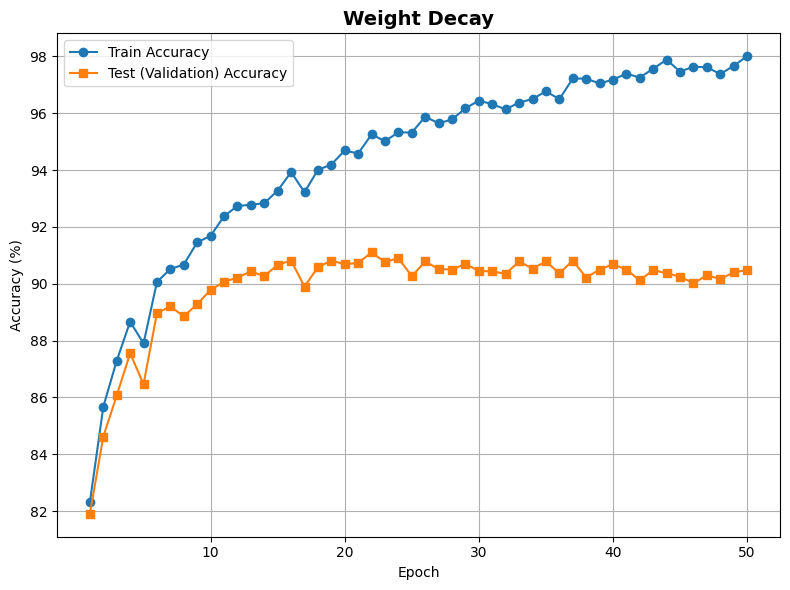

In [20]:
plot(results["Weight Decay"], "Weight Decay")

In [5]:
results["BatchNorm"] = run_experiment(

    model=LeNet5BatchNorm(),

    name="LeNet-5 + Batch Normalization",

    save_filename="lenet5_batchnorm.pth",

    weight_decay=0.0,

    epochs=EPOCHS
)


Training: LeNet-5 + Batch Normalization
Epoch [ 1/50] | Loss: 0.4334 | Train Acc: 89.46% | Val Acc: 88.60% 
Epoch [ 2/50] | Loss: 0.2935 | Train Acc: 90.46% | Val Acc: 89.35% 
Epoch [ 3/50] | Loss: 0.2581 | Train Acc: 90.73% | Val Acc: 88.95% 
Epoch [ 4/50] | Loss: 0.2352 | Train Acc: 91.55% | Val Acc: 89.83% 
Epoch [ 5/50] | Loss: 0.2187 | Train Acc: 93.46% | Val Acc: 90.90% 
Epoch [ 6/50] | Loss: 0.2009 | Train Acc: 93.71% | Val Acc: 90.67% 
Epoch [ 7/50] | Loss: 0.1878 | Train Acc: 93.95% | Val Acc: 90.87% 
Epoch [ 8/50] | Loss: 0.1781 | Train Acc: 95.00% | Val Acc: 91.48% 
Epoch [ 9/50] | Loss: 0.1692 | Train Acc: 94.99% | Val Acc: 91.47% 
Epoch [10/50] | Loss: 0.1570 | Train Acc: 95.27% | Val Acc: 90.78% 
Epoch [11/50] | Loss: 0.1470 | Train Acc: 95.91% | Val Acc: 91.20% 
Epoch [12/50] | Loss: 0.1380 | Train Acc: 95.69% | Val Acc: 90.87% 
Epoch [13/50] | Loss: 0.1315 | Train Acc: 95.91% | Val Acc: 90.85% 
Epoch [14/50] | Loss: 0.1239 | Train Acc: 96.31% | Val Acc: 91.07% 
Epoch [

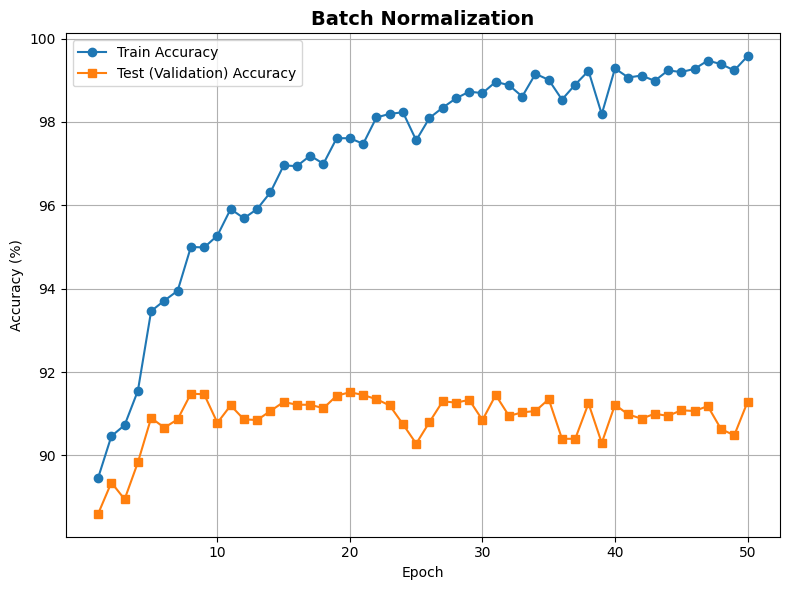

In [8]:
plot(results["BatchNorm"], "Batch Normalization")

In [10]:
model_files = {
    "Base": ("lenet5_base.pth", LeNet5Base),
    "Dropout": ("lenet5_dropout.pth", LeNet5Dropout),
    "Weight Decay": ("lenet5_weight_decay.pth", LeNet5Base),
    "BatchNorm": ("lenet5_batchnorm.pth", LeNet5BatchNorm)
}


accuracy_results = []


for name, (file, model_class) in model_files.items():

    model = model_class().to(device)

    model.load_state_dict(
        torch.load(
            file,
            map_location=device
        )
    )

    train_acc = compute_accuracy(
        model,
        train_loader
    )

    val_acc = compute_accuracy(
        model,
        val_loader
    )

    test_acc = compute_accuracy(
        model,
        test_loader
    )

    accuracy_results.append({
        "Model": name,
        "Train Accuracy (%)": train_acc,
        "Validation Accuracy (%)": val_acc,
        "Test Accuracy (%)": test_acc
    })


accuracy_table = pd.DataFrame(accuracy_results)

accuracy_table = accuracy_table.round(2)

accuracy_table

,Model,Train Accuracy (%),Validation Accuracy (%),Test Accuracy (%)
0,Base,97.44,91.03,90.49
1,Dropout,94.18,91.67,90.65
2,Weight Decay,95.26,91.10,90.98
3,BatchNorm,97.61,91.52,90.64


### Conclusion

All four LeNet-5 configurations achieved more than 88% test accuracy. The model with Batch Normalization achieved the highest test accuracy at 90.91% and also had the highest validation accuracy, showing the strongest overall performance in this experiment. Dropout achieved a test accuracy of 89.19% and had the smallest gap between training and test accuracy, which suggests stronger regularization and less overfitting. Weight Decay achieved 88.99% test accuracy, which was slightly lower than the baseline model's 89.70%. Overall, Batch Normalization improved performance the most, while Dropout was more effective at reducing the gap between training and test accuracy.